<a href="https://colab.research.google.com/github/nelsbuhrley/CSE-450-Machine-learning/blob/main/notebooks/hint_decisiontrees_polars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# Load some test data
import polars as pl
import sklearn as skl
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split
import numpy as np

data = pl.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv',schema_overrides={'nr.employed':float})
# Round 'nr.employed' to the nearest whole number and cast to integer
data = data.with_columns(pl.col('nr.employed').round(0).cast(pl.Int64))

print(data.select(pl.col('loan')).unique())
data.sample(10)

data.with_columns(pl.col(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']).cast(pl.Categorical))


shape: (3, 1)
┌─────────┐
│ loan    │
│ ---     │
│ str     │
╞═════════╡
│ no      │
│ unknown │
│ yes     │
└─────────┘


age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
i64,cat,cat,cat,cat,cat,cat,cat,cat,cat,i64,i64,i64,cat,f64,f64,f64,f64,i64,cat
56,"""housemaid""","""married""","""basic.4y""","""no""","""no""","""no""","""telephone""","""may""","""mon""",1,999,0,"""nonexistent""",1.1,93.994,-36.4,4.857,5191,"""no"""
57,"""services""","""married""","""high.school""","""unknown""","""no""","""no""","""telephone""","""may""","""mon""",1,999,0,"""nonexistent""",1.1,93.994,-36.4,4.857,5191,"""no"""
37,"""services""","""married""","""high.school""","""no""","""yes""","""no""","""telephone""","""may""","""mon""",1,999,0,"""nonexistent""",1.1,93.994,-36.4,4.857,5191,"""no"""
40,"""admin.""","""married""","""basic.6y""","""no""","""no""","""no""","""telephone""","""may""","""mon""",1,999,0,"""nonexistent""",1.1,93.994,-36.4,4.857,5191,"""no"""
56,"""services""","""married""","""high.school""","""no""","""no""","""yes""","""telephone""","""may""","""mon""",1,999,0,"""nonexistent""",1.1,93.994,-36.4,4.857,5191,"""no"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
73,"""retired""","""married""","""professional.course""","""no""","""yes""","""no""","""cellular""","""nov""","""fri""",1,999,0,"""nonexistent""",-1.1,94.767,-50.8,1.028,4964,"""yes"""
46,"""blue-collar""","""married""","""professional.course""","""no""","""no""","""no""","""cellular""","""nov""","""fri""",1,999,0,"""nonexistent""",-1.1,94.767,-50.8,1.028,4964,"""no"""
56,"""retired""","""married""","""university.degree""","""no""","""yes""","""no""","""cellular""","""nov""","""fri""",2,999,0,"""nonexistent""",-1.1,94.767,-50.8,1.028,4964,"""no"""


In [20]:
##lets seperate out some values

data = data.with_columns([
    pl.when(pl.col('day_of_week').is_in(['tue', 'wed', 'thu']))
        .then(1)
        .otherwise(0)
        .alias('is_twr')
]).with_columns(
    pl.when(pl.col('nr.employed') < 5101).then(pl.lit('nr_employed_med'))
    .when(pl.col('nr.employed') < 5001).then(pl.lit('nr_employed_low'))
    .otherwise(pl.lit('nr_employed_high'))
    .alias('nr_employed_category')
)

print(data.select('is_twr').unique())

# Re-define features to ensure it's a list of strings for categorical columns, 'campaign'
features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'pdays', 'previous', 'nr_employed_category']

# Create a list of all columns to be included in x
selected_x_columns = features + ['is_twr']

# Select these columns from data and then apply to_dummies to the categorical ones
# Polars to_dummies on a DataFrame will dummify the specified columns and retain others.
x = data.select(selected_x_columns).to_dummies(features, drop_first=True)

y = data.select(pl.col('y'))

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.10)

# Reshape y_train and y_test to 1D arrays to avoid DataConversionWarning
y_train_raveled = y_train.to_series().to_numpy().ravel()
y_test_raveled = y_test.to_series().to_numpy().ravel()

clf1 = skl.ensemble.RandomForestClassifier(max_depth = 4)
clf1.fit(x_train, y_train_raveled)
print(clf1.score(x_test, y_test_raveled))

clf2 = DecisionTreeClassifier(max_depth=4)
clf2.fit(x_train, y_train_raveled)
print(clf2.score(x_test, y_test_raveled))

shape: (2, 1)
┌────────┐
│ is_twr │
│ ---    │
│ i32    │
╞════════╡
│ 0      │
│ 1      │
└────────┘
0.8885891556514702
0.8937145940113299


In [21]:
ver = pl.read_csv('/Users/nelsbuhrley/All Software Development/CSE-450-Machine-learning/bank-data/bank-additional-full_minus_bank.csv', schema_overrides={'nr.employed':float})
ver = ver.with_columns(pl.col('nr.employed').round(0).cast(pl.Int64))
ver.sample(10)

age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
i64,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,str,f64,f64,f64,f64,i64,str
47,"""admin.""","""married""","""university.degree""","""no""","""no""","""no""","""telephone""","""jun""","""fri""",143,1,999,0,"""nonexistent""",1.4,94.465,-41.8,4.967,5228,"""no"""
39,"""admin.""","""married""","""high.school""","""unknown""","""yes""","""no""","""telephone""","""jun""","""thu""",71,6,999,0,"""nonexistent""",1.4,94.465,-41.8,4.958,5228,"""no"""
40,"""blue-collar""","""married""","""basic.4y""","""no""","""no""","""yes""","""cellular""","""nov""","""mon""",143,2,999,0,"""nonexistent""",-0.1,93.2,-42.0,4.191,5196,"""no"""
29,"""blue-collar""","""married""","""basic.6y""","""no""","""no""","""no""","""cellular""","""may""","""thu""",123,4,999,0,"""nonexistent""",-1.8,92.893,-46.2,1.266,5099,"""no"""
31,"""admin.""","""single""","""basic.9y""","""no""","""no""","""no""","""telephone""","""jun""","""thu""",105,2,999,0,"""nonexistent""",1.4,94.465,-41.8,4.866,5228,"""no"""
44,"""blue-collar""","""married""","""basic.6y""","""no""","""no""","""no""","""cellular""","""apr""","""mon""",400,1,999,0,"""nonexistent""",-1.8,93.075,-47.1,1.405,5099,"""no"""
59,"""self-employed""","""married""","""professional.course""","""unknown""","""no""","""no""","""cellular""","""nov""","""fri""",383,4,999,1,"""failure""",-0.1,93.2,-42.0,4.021,5196,"""no"""
41,"""technician""","""married""","""high.school""","""no""","""no""","""no""","""cellular""","""aug""","""wed""",209,3,999,0,"""nonexistent""",1.4,93.444,-36.1,4.967,5228,"""no"""
41,"""blue-collar""","""married""","""basic.6y""","""unknown""","""yes""","""no""","""telephone""","""may""","""fri""",160,6,999,0,"""nonexistent""",1.1,93.994,-36.4,4.859,5191,"""no"""


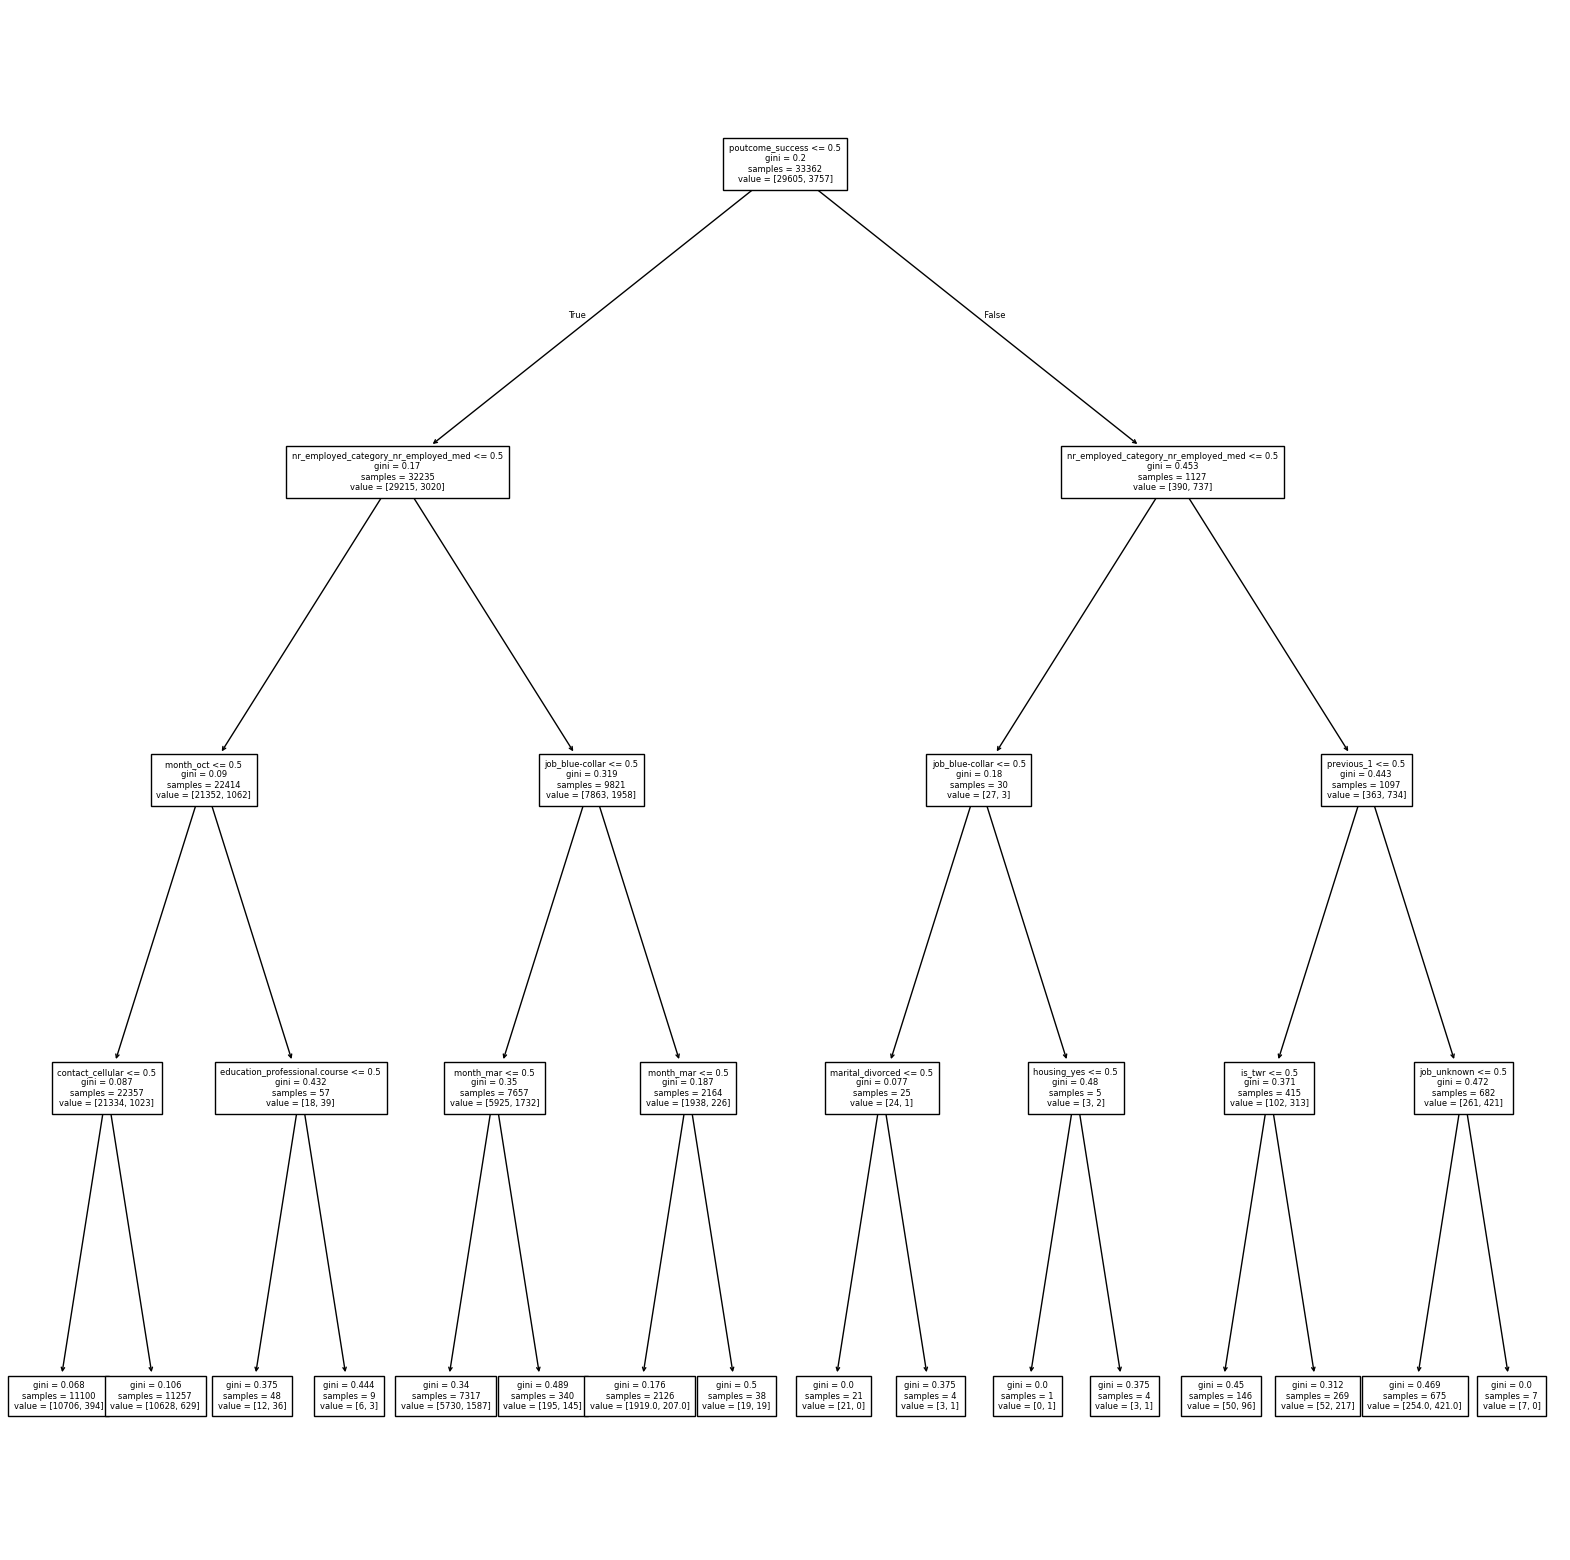

In [252]:
# Let's visualize the tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 20))
tree.plot_tree(clf2, fontsize=6, feature_names=x.columns)
plt.show()